---

Nội dung mà nhóm đã triển khai trong bài
-----

Mục tiêu của đồ án này là xây dựng được model:
 1. Model mạng nơ-ron `Neural Network`

## I.NEURAL NETWORK  

### 1. Làm sạch dữ liệu & Khai phá dữ liệu

In [92]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sklearn
import keras
from sklearn.model_selection import train_test_split 
tf.keras.utils.set_random_seed(0)

Tại đây em sẽ chia bộ dữ liệu theo tỉ lệ (6,2,2)  
| Bộ dữ liệu| Tỉ lệ|
|------:|----------------:|
|Train|6|
|Validation| 2|
|Test|2|

Code tải dữ liệu từ Kaggle

In [93]:

# import pandas as pd
# import os
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("teejmahal20/airline-passenger-satisfaction")

# print("Path to dataset files:", path)

# train_file_path = os.path.join(path, "train.csv")
# test_file_path = os.path.join(path, "test.csv")
# # 3. Đọc dữ liệu vào Pandas DataFrame
# train = pd.read_csv(train_file_path)
# test  = pd.read_csv(test_file_path)

In [94]:
# tải dữ liệu lên VSCODE
test= pd.read_csv('test.csv')
train= pd.read_csv('train.csv')
# Tách bộ train ra thành 2 bộ Train và Validation
train, val = train_test_split(train,test_size=0.25, random_state=42)


In [95]:
train

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
22672,22672,31605,Male,Loyal Customer,11,Personal Travel,Eco,602,1,4,...,3,3,4,5,4,4,3,3,2.0,neutral or dissatisfied
13770,13770,129614,Male,Loyal Customer,45,Business travel,Business,447,4,4,...,2,2,2,2,5,2,5,0,0.0,satisfied
47909,47909,27346,Female,Loyal Customer,42,Business travel,Eco,956,4,1,...,3,3,4,3,5,3,2,0,0.0,satisfied
29822,29822,11158,Female,Loyal Customer,51,Personal Travel,Eco,163,3,4,...,4,4,3,4,2,4,2,0,0.0,neutral or dissatisfied
52456,52456,19014,Male,Loyal Customer,33,Business travel,Business,3218,2,5,...,2,4,1,3,3,3,2,0,23.0,neutral or dissatisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54886,54886,118014,Male,disloyal Customer,39,Business travel,Eco,637,3,5,...,3,4,3,2,3,2,3,1,0.0,neutral or dissatisfied
76820,76820,88599,Male,Loyal Customer,17,Personal Travel,Eco,646,3,4,...,3,5,1,2,4,4,3,0,2.0,neutral or dissatisfied
103694,103694,36593,Male,Loyal Customer,46,Business travel,Eco,1197,1,2,...,4,3,3,3,1,1,1,260,263.0,neutral or dissatisfied
860,860,38896,Female,Loyal Customer,37,Business travel,Eco,320,5,5,...,5,1,2,4,1,3,5,0,0.0,satisfied


Kiểm tra thông tin tổng quan của bộ dữ liệu:
- Bộ dữ liệu có *25* cột ( *19: int, 1: float, 5: string* ) với tổng *129880* dòng dữ liệu
- Tại cột `Arrival Delay in Minutes` của cả 3 bộ đều có các giá trị bị NaN

In [96]:
train.info()

<class 'pandas.DataFrame'>
Index: 77928 entries, 22672 to 15795
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         77928 non-null  int64  
 1   id                                 77928 non-null  int64  
 2   Gender                             77928 non-null  str    
 3   Customer Type                      77928 non-null  str    
 4   Age                                77928 non-null  int64  
 5   Type of Travel                     77928 non-null  str    
 6   Class                              77928 non-null  str    
 7   Flight Distance                    77928 non-null  int64  
 8   Inflight wifi service              77928 non-null  int64  
 9   Departure/Arrival time convenient  77928 non-null  int64  
 10  Ease of Online booking             77928 non-null  int64  
 11  Gate location                      77928 non-null  int64  
 12  Fo

In [97]:
val.info()

<class 'pandas.DataFrame'>
Index: 25976 entries, 80638 to 86514
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         25976 non-null  int64  
 1   id                                 25976 non-null  int64  
 2   Gender                             25976 non-null  str    
 3   Customer Type                      25976 non-null  str    
 4   Age                                25976 non-null  int64  
 5   Type of Travel                     25976 non-null  str    
 6   Class                              25976 non-null  str    
 7   Flight Distance                    25976 non-null  int64  
 8   Inflight wifi service              25976 non-null  int64  
 9   Departure/Arrival time convenient  25976 non-null  int64  
 10  Ease of Online booking             25976 non-null  int64  
 11  Gate location                      25976 non-null  int64  
 12  Fo

In [98]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 25976 entries, 0 to 25975
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         25976 non-null  int64  
 1   id                                 25976 non-null  int64  
 2   Gender                             25976 non-null  str    
 3   Customer Type                      25976 non-null  str    
 4   Age                                25976 non-null  int64  
 5   Type of Travel                     25976 non-null  str    
 6   Class                              25976 non-null  str    
 7   Flight Distance                    25976 non-null  int64  
 8   Inflight wifi service              25976 non-null  int64  
 9   Departure/Arrival time convenient  25976 non-null  int64  
 10  Ease of Online booking             25976 non-null  int64  
 11  Gate location                      25976 non-null  int64  
 12  F

In [123]:
train[train['satisfaction'] == 'satisfied'].shape

(33726, 23)

In [124]:
train[train['satisfaction'] != 'satisfied'].shape

(44202, 23)

In [99]:
# Xóa duplicate của 3 bộ dữ liệu
print("Số lượng trùng lập của bộ dữ liệu:",train.duplicated().sum())
print("Số lượng trùng lập của bộ dữ liệu:",val.duplicated().sum())
print("Số lượng trùng lập của bộ dữ liệu:",test.duplicated().sum())
train.drop_duplicates(inplace=True)
val.drop_duplicates(inplace=True)
test.drop_duplicates(inplace=True)

Số lượng trùng lập của bộ dữ liệu: 0
Số lượng trùng lập của bộ dữ liệu: 0
Số lượng trùng lập của bộ dữ liệu: 0


In [100]:
# Xóa 2 cột Unnamed: 0 và ID
drop_cols= ['Unnamed: 0','id'] 
train= train.drop(columns= drop_cols, axis=0)
val= val.drop(columns= drop_cols, axis=0)
test= test.drop(columns= drop_cols, axis=0)

Tiến hành kiểm tra các giá trị của bộ `train`

In [101]:
train.describe()

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,77928.000000,77928.000000,77928.000000,77928.000000,77928.000000,77928.000000,77928.000000,77928.000000,77928.000000,77928.000000,77928.000000,77928.000000,77928.000000,77928.000000,77928.000000,77928.000000,77928.000000,77692.000000
mean,39.324505,1189.586926,2.728762,3.054794,2.755479,2.976735,3.200159,3.244995,3.434683,3.354019,3.383841,3.353814,3.630082,3.305538,3.640643,3.281401,14.810132,15.157056
std,15.116653,997.158243,1.327773,1.528224,1.399307,1.275678,1.326836,1.351390,1.319103,1.330146,1.287472,1.313913,1.181238,1.265600,1.174949,1.310126,38.273624,38.727214
min,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,413.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,40.000000,842.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,51.000000,1744.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


Tổng hợp thông tin và các bước mà nhóm em đã khám phá dữ liệu của bộ train: cụ thể là khám phá tỉ lệ của `satisfied` và `other` trong `Outlier` và bộ `train`  

 | Description | Percent |
 |-----------------:|----------------:|
 | Tỉ lệ dữ liệu outlier so với tập train | 1.0009% |
 | Tỉ lệ dữ liệu 'satisfied' trong outlier | 77.4359% |
 | Tỉ lệ dữ liệu nhóm còn lại trong outlier | 22.5641% |
 | Tỉ lệ outlier nằm trong toàn bộ nhóm 'satisfied' | 1.7909% |
 | Tỉ lệ outlier nằm trong toàn bộ nhóm còn lại | 1.3665% |

Tuy tỉ lệ của dữ liệu `outlier` không cao những tụi em vẫn sẽ giữ chúng lại thay vì là xóa bỏ

In [102]:
upper_bound = train['Flight Distance'].quantile(0.99)
outlier_shape= train[train['Flight Distance'] > upper_bound].shape
train_shape= train.shape
train_satisfied_shape = train[train['satisfaction'] == 'satisfied'].shape
train_dissatisfied_shape = train[train['satisfaction'] != 'satisfied'].shape

In [103]:
x= outlier_shape[0]
y= train_shape[0]
outlier_percen = (x/y)*100
print(f"Tỉ lệ dữ liệu outlier so với bộ train: {outlier_percen:.4f}")

Tỉ lệ dữ liệu outlier so với bộ train: 1.0009


In [104]:
x= train[(train['Flight Distance'] > upper_bound )& (train['satisfaction'] != 'satisfied')].shape
y= train[(train['Flight Distance'] > upper_bound )& (train['satisfaction'] == 'satisfied')].shape

neural_or_dissatisfied= (x[0]/(x[0]+y[0])*100)
satisfied_percen = (y[0]/(x[0]+y[0])*100)

In [105]:
print(f"Tỉ lệ dữ liệu satisfaction trong outlier : {satisfied_percen:.4f}") 
print(f"Tỉ lệ dữ liệu neural or dissatisfied trong outlier: {neural_or_dissatisfied:.4f}")

Tỉ lệ dữ liệu satisfaction trong outlier : 77.4359
Tỉ lệ dữ liệu neural or dissatisfied trong outlier: 22.5641


In [106]:
satisfied_outlier_train = (y[0]/train_satisfied_shape[0])*100
dissatisfied_outlier_train = (y[0]/train_dissatisfied_shape[0])*100

print(f"Tỉ lệ dữ liệu satisfaction của outlier trong toàn bộ train: {satisfied_outlier_train:.4f}")
print(f"Tỉ lệ dữ liệu nhóm còn lại của outlier trong toàn bộ train: {dissatisfied_outlier_train:.4f}")

Tỉ lệ dữ liệu satisfaction của outlier trong toàn bộ train: 1.7909
Tỉ lệ dữ liệu nhóm còn lại của outlier trong toàn bộ train: 1.3665


Kiểm tra các giá trị có trong từng cột trong 3 bộ

In [107]:
df_col = train.columns
for col_name in df_col[0:5]:
    unique_values = train[col_name].unique()
    print('------------------------')
    print(f"{col_name}: {unique_values}")


------------------------
Gender: <StringArray>
['Male', 'Female']
Length: 2, dtype: str
------------------------
Customer Type: <StringArray>
['Loyal Customer', 'disloyal Customer']
Length: 2, dtype: str
------------------------
Age: [11 45 42 51 33 49 69 64 43 23 72 48 18 36 17 30 57 41 16 58 31 61 35 13
 44 27 28 25 19 39 10 60 26 50 21 29 53 46 55 62 22 70 24 47 40 59 37 54
 38  8 56 79 67 65 20 32 34  9 75 12 68 52 71  7 77 63 66 14 15 80 78 73
 76 74 85]
------------------------
Type of Travel: <StringArray>
['Personal Travel', 'Business travel']
Length: 2, dtype: str
------------------------
Class: <StringArray>
['Eco', 'Business', 'Eco Plus']
Length: 3, dtype: str


In [108]:
df_col = val.columns
for col_name in df_col[0:5]:
    unique_values = val[col_name].unique()
    print('------------------------')
    print(f"{col_name}: {unique_values}")


------------------------
Gender: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
------------------------
Customer Type: <StringArray>
['Loyal Customer', 'disloyal Customer']
Length: 2, dtype: str
------------------------
Age: [26 22 59 32 35 25 34 39 45 31 50 42 24 23 12 41 30 20 63 51 40 21 28 36
 49 37 43 44 74 29 70 14 72 57 47 54 52 56 60  9 46 55 33 16 67 27 19 66
 64 15 58 38  8 13 75  7 53 61 10 17 69 65 48 62 68 77 11 18 76 78 71 79
 80 73 85]
------------------------
Type of Travel: <StringArray>
['Personal Travel', 'Business travel']
Length: 2, dtype: str
------------------------
Class: <StringArray>
['Eco', 'Business', 'Eco Plus']
Length: 3, dtype: str


In [109]:
df_col = test.columns
for col_name in df_col[0:5]:
    unique_values = test[col_name].unique()
    print('------------------------')
    print(f"{col_name}: {unique_values}")


------------------------
Gender: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
------------------------
Customer Type: <StringArray>
['Loyal Customer', 'disloyal Customer']
Length: 2, dtype: str
------------------------
Age: [52 36 20 44 49 16 77 43 47 46 33 60 50 31 55 25 30 62 24 22 51 56 41 53
 12 39 32 40 42 28 59 58 27 67 70 66 19 69 35 54 26 61 21 37 45 38  7 34
 17 15 48 13 11 29  8 18 23 65 57 80 64  9 14 68 10 79 63 73 74 71 72 76
 78 75 85]
------------------------
Type of Travel: <StringArray>
['Business travel', 'Personal Travel']
Length: 2, dtype: str
------------------------
Class: <StringArray>
['Eco', 'Business', 'Eco Plus']
Length: 3, dtype: str


Tạo 2 biểu đồ `Boxplot` và `Histplot` để quan sát độ phân tán và giá trị phân phối của dữ liệu

Thông qua biểu đồ chúng ta thấy được trực quan hơn dữ liệu lệch phải của 3 cột `Arrival Delay in Minutes`, `Departure Delay in Minutes`, `Flight Distance`

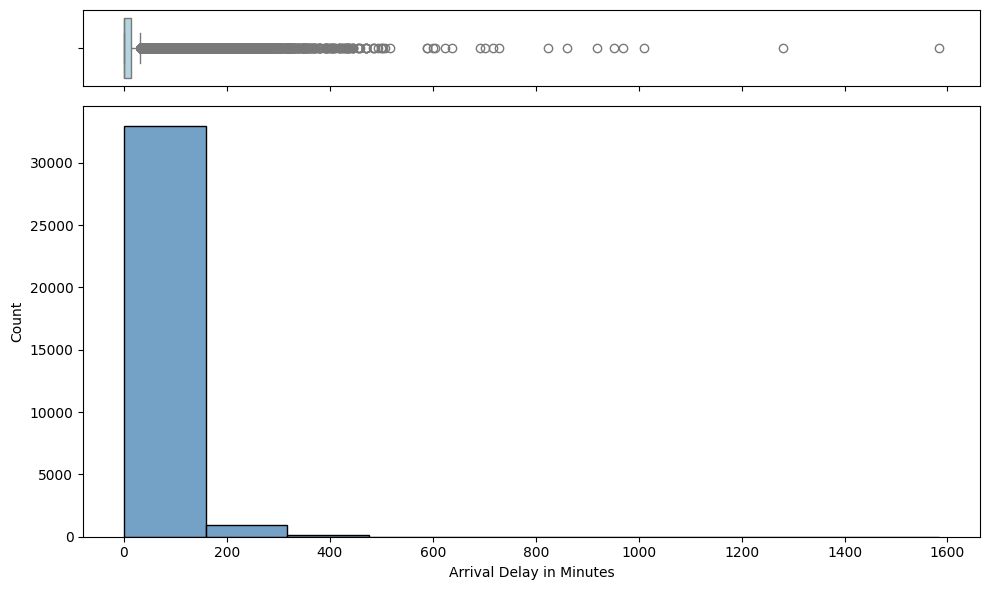

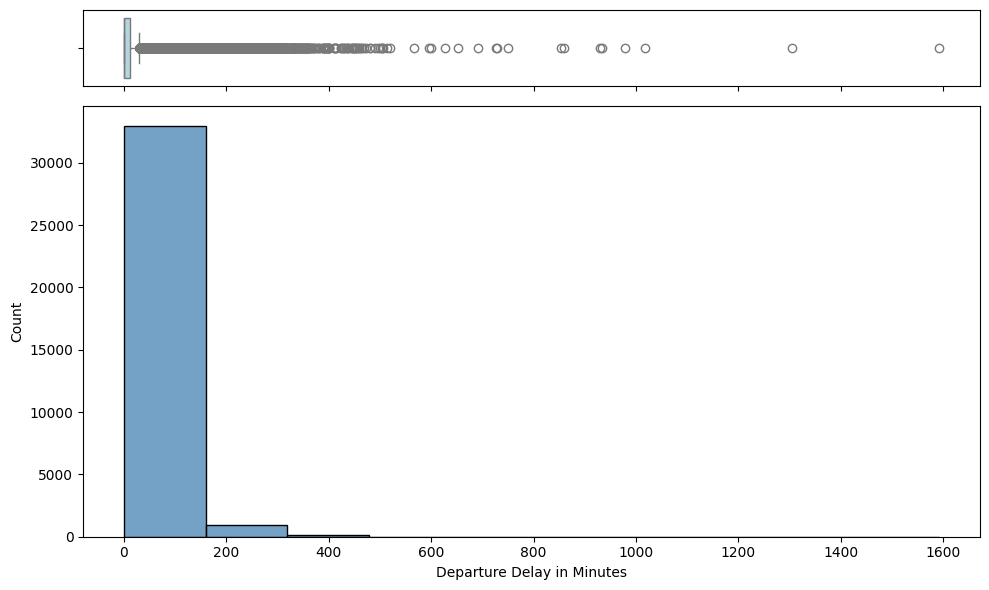

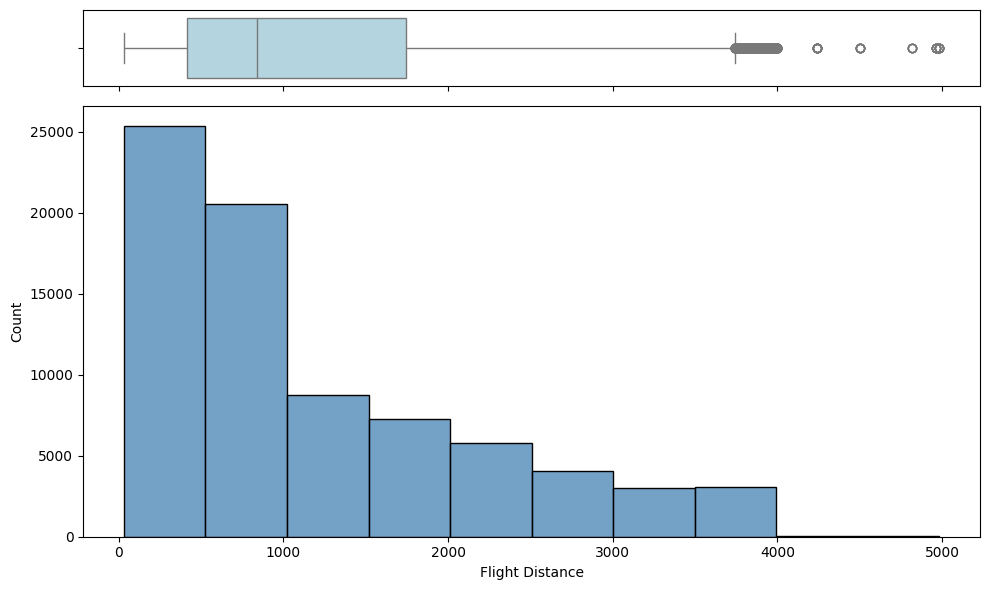

In [110]:
import matplotlib.pyplot as plt
import seaborn as sns

cols_to_plot = ['Arrival Delay in Minutes', 'Departure Delay in Minutes','Flight Distance']
for col in cols_to_plot:
    filtered_train = train[train[col] > 0] # do có quá nhiều dữ liệu ở giá trị 0 nên em sẽ loại bỏ 0 để dễ nhìn các giá trị còn lại
    fig, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)}, figsize=(10, 6))
    sns.boxplot(x=train[col], ax=ax_box, color='lightblue')
    sns.histplot(data=filtered_train, x=col, ax=ax_hist, bins=10, color='steelblue')
    plt.tight_layout()
    plt.show()

Xử lý các giá trị bị NaN bằng phương pháp `Meadian` do bộ dữ liệu bị lệch rất nặng ở cột `Arrival Delay in Minutes`  


In [111]:
from sklearn.impute import SimpleImputer
df_trans = train[['Arrival Delay in Minutes']]
val_trans= val[['Arrival Delay in Minutes']]
test_trans= test[['Arrival Delay in Minutes']]

imp_median = SimpleImputer(missing_values=np.nan,strategy='median')
imp_median.fit(df_trans)

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [112]:
# Chuyển output trên về lại dataframe
df_trans = pd.DataFrame(imp_median.transform(df_trans),
                          columns=df_trans.columns,
                          index=df_trans.index)

val_trans= pd.DataFrame(imp_median.transform(val_trans),
                          columns=val_trans.columns,
                          index=val_trans.index)

test_trans = pd.DataFrame(imp_median.transform(test_trans),
                          columns=test_trans.columns,
                          index=test_trans.index)

In [113]:
train.update(df_trans)
val.update(val_trans)
test.update(test_trans)

Dưới đây là 3 function mà em đã tạo, để phục vụ cho các mục địch xử lý dữ liệu cho bài
1. **remove_outlier_IQR**
    - Đây là hàm dùng để tìm kiếm các giá trị outlier bằng phương pháp IQR  
    - Dùng tính năng tứ phân vị để đưa ra giá trị IQR (Q3-Q1) sau đó tạo ra 2 giá trị là cận dưới (lower_bound) và cận trên (upper_bound)
    - dùng `.clip` để gán giá trị lower và upper cho các outlier vượt qua giá trị này, tránh việc xóa các giá trị outlier làm mất thông tin quan trọng
2. **outlier_99_percen**
    - Đây cũng là 1 phương pháp tìm kiếm và gán các giá trị của outlier nhưng là ở phân vị thứ 99 (99%) của dữ liệu
    - Dùng `.quantile` kết hợp với biến `lower_percentile` và `upper_percentile` tại bài này thì chỉ áp dụng ở 2 cột là `Departure Delay in Minutes` và `Arrival Delay in Minutes` nên sẽ không có giá trị âm, em sẽ dùng lower là 0.0 và upper là 0.99 (99% dữ liệu).
    - Mục đích của hàm này là lấy 99% dữ liệu làm một bound, các giá trị vượt qua thì sẽ bị gán lại bằng chính giá trị của bound
3. **outliers_3percentile ($3\sigma$)**
    - Đây là hàm gán giá trị theo quy tắc $3\sigma$
    - Dùng chỉ số `mean` và `std` của cột dữ liệu cho ra 2 chốt chặn trên và dưới
    - Do dữ liệu ở 2 cột `Departure Delay in Minutes` và `Arrival Delay in Minutes` bị lệch phải nặng nên sẽ không khuyến khích dùng phương pháp này

In [114]:
# Hàm bỏ các giá trị outline bằng phương pháp IQR
def remove_outliers_IQR(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5* IQR
        print(f"Cột '{col}': Chặn dưới = {lower_bound:.2f}, Chặn trên = {upper_bound:.2f}")
        
        df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
    return df

# Hàm gán các giá trị outlier về mức giới hạn phân vị (99%)
def outliers_99_percen(df, columns, lower_percentile=0.0, upper_percentile=0.99):
    for col in columns:
        lower_bound = df[col].quantile(lower_percentile)
        upper_bound = df[col].quantile(upper_percentile)
        print(f"Cột '{col}': Chặn dưới = {lower_bound:.2f}, Chặn trên (mốc {upper_percentile*100}%) = {upper_bound:.2f}")

        df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
    return df

# Hàm này giới hạn các giá trị theo quy tắc phân vị
def outliers_3percentile(df, columns):
    for col in columns:
        mean = df[col].mean()
        std = df[col].std()
        upper_bound = mean + 3 * std
        lower_bound = mean - 3 * std
        print(f"Cột '{col}': Chặn dưới = {lower_bound:.2f}, Chặn trên = {upper_bound:.2f}")

        df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
    return df

Tại đây nhóm em sẽ sử dụng 3 function phía trên có giới thiệu để xử lý các giá trị Outlier

In [115]:
columns_to_cap = ['Departure Delay in Minutes', 'Arrival Delay in Minutes','Flight Distance']

In [ ]:
# Áp dụng hàm với giới hạn ở 99%
train = outliers_99_percen(train, columns=columns_to_cap, upper_percentile=0.99)
val = outliers_99_percen(val, columns=columns_to_cap, upper_percentile=0.99)
test = outliers_99_percen(test, columns=columns_to_cap, upper_percentile=0.99)

Cột 'Departure Delay in Minutes': Chặn dưới = 0.00, Chặn trên (mốc 99.0%) = 181.73
Cột 'Arrival Delay in Minutes': Chặn dưới = 0.00, Chặn trên (mốc 99.0%) = 183.00
Cột 'Flight Distance': Chặn dưới = 31.00, Chặn trên (mốc 99.0%) = 3879.73
Cột 'Departure Delay in Minutes': Chặn dưới = 0.00, Chặn trên (mốc 99.0%) = 181.25
Cột 'Arrival Delay in Minutes': Chặn dưới = 0.00, Chặn trên (mốc 99.0%) = 185.00
Cột 'Flight Distance': Chặn dưới = 31.00, Chặn trên (mốc 99.0%) = 3889.00
Cột 'Departure Delay in Minutes': Chặn dưới = 0.00, Chặn trên (mốc 99.0%) = 168.00
Cột 'Arrival Delay in Minutes': Chặn dưới = 0.00, Chặn trên (mốc 99.0%) = 172.00
Cột 'Flight Distance': Chặn dưới = 31.00, Chặn trên (mốc 99.0%) = 3889.00


In [ ]:
# # Áp dụng hàm với giới hạn IQR
# train = remove_outliers_IQR(train,columns_to_cap)
# val = remove_outliers_IQR(val,columns_to_cap)
# test = remove_outliers_IQR(test,columns_to_cap)

Cột 'Departure Delay in Minutes': Chặn dưới = -18.00, Chặn trên = 30.00
Cột 'Arrival Delay in Minutes': Chặn dưới = -19.50, Chặn trên = 32.50
Cột 'Flight Distance': Chặn dưới = -1583.50, Chặn trên = 3740.50
Cột 'Departure Delay in Minutes': Chặn dưới = -18.00, Chặn trên = 30.00
Cột 'Arrival Delay in Minutes': Chặn dưới = -19.50, Chặn trên = 32.50
Cột 'Flight Distance': Chặn dưới = -1570.88, Chặn trên = 3722.12
Cột 'Departure Delay in Minutes': Chặn dưới = -18.00, Chặn trên = 30.00
Cột 'Arrival Delay in Minutes': Chặn dưới = -19.50, Chặn trên = 32.50
Cột 'Flight Distance': Chặn dưới = -1581.00, Chặn trên = 3739.00


In [116]:
# # Áp dụng hàm với giới hạn 3_percentile
# train = outliers_3percentile(train,columns_to_cap)
# val = outliers_3percentile(val,columns_to_cap)
# test = outliers_3percentile(test,columns_to_cap)

Cột 'Departure Delay in Minutes': Chặn dưới = -100.01, Chặn trên = 129.63
Cột 'Arrival Delay in Minutes': Chặn dưới = -100.92, Chặn trên = 131.14
Cột 'Flight Distance': Chặn dưới = -1801.89, Chặn trên = 4181.06
Cột 'Departure Delay in Minutes': Chặn dưới = -99.48, Chặn trên = 129.14
Cột 'Arrival Delay in Minutes': Chặn dưới = -100.50, Chặn trên = 130.90
Cột 'Flight Distance': Chặn dưới = -1802.37, Chặn trên = 4180.43
Cột 'Departure Delay in Minutes': Chặn dưới = -97.96, Chặn trên = 126.58
Cột 'Arrival Delay in Minutes': Chặn dưới = -97.71, Chặn trên = 127.09
Cột 'Flight Distance': Chặn dưới = -1802.26, Chặn trên = 4189.84


Tại đây em sẽ copy lại đoạn code tạo biểu đồ để trực quan giá trị của các cột đã được xử lý outlier.  


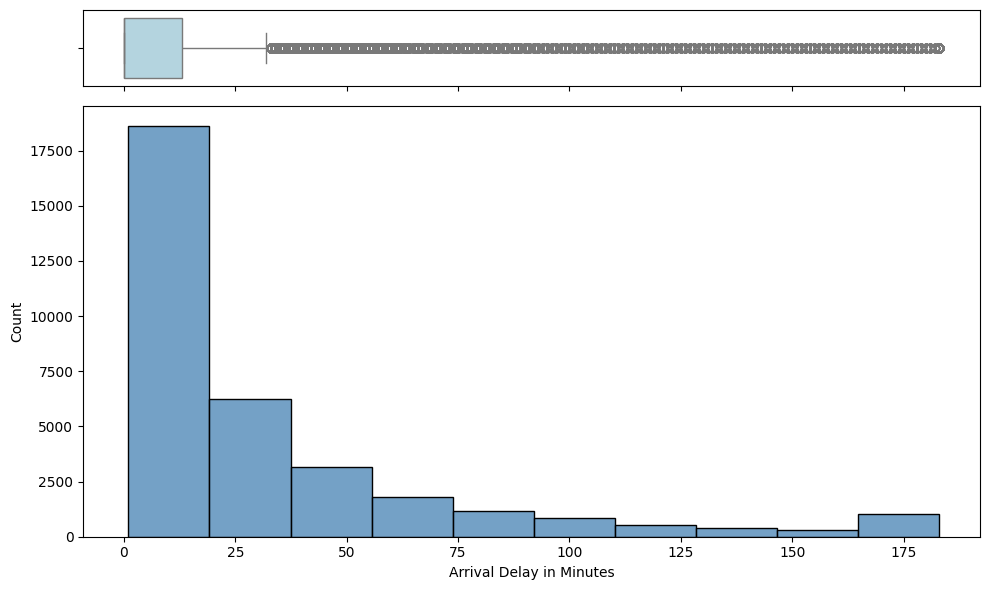

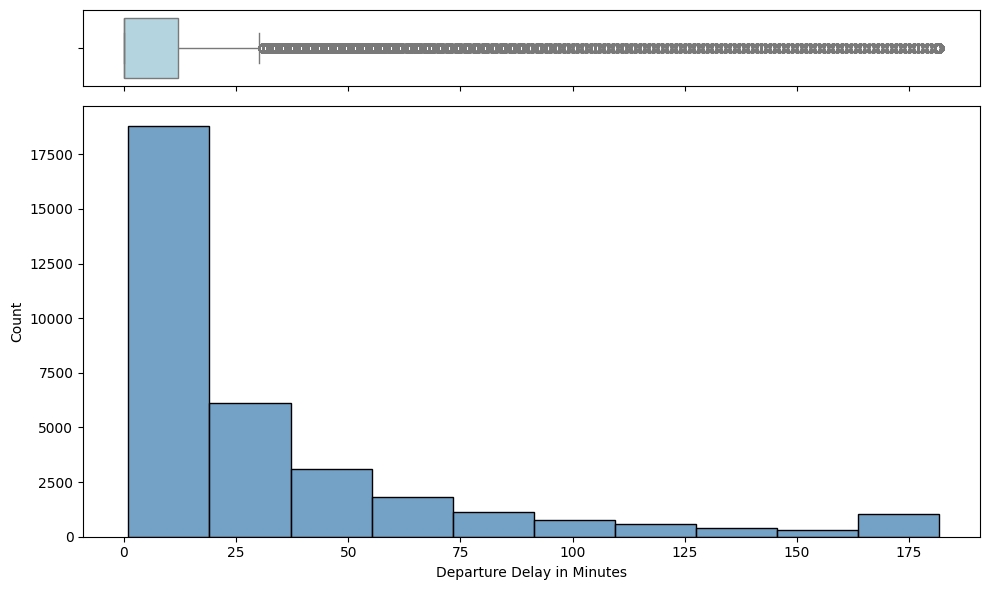

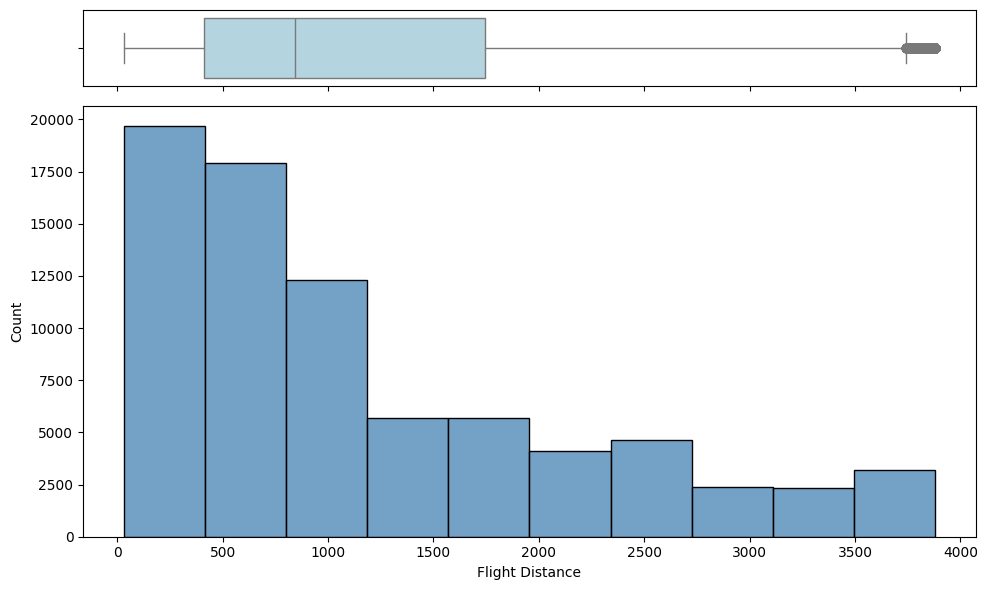

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cols_to_plot = ['Arrival Delay in Minutes', 'Departure Delay in Minutes','Flight Distance']
for col in cols_to_plot:
    filtered_train = train[train[col] > 0] # do có quá nhiều dữ liệu ở giá trị 0 nên em sẽ loại bỏ 0 để dễ nhìn các giá trị còn lại
    fig, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)}, figsize=(10, 6))
    sns.boxplot(x=train[col], ax=ax_box, color='lightblue')
    sns.histplot(data=filtered_train, x=col, ax=ax_hist, bins=10, color='steelblue')
    plt.tight_layout()
    plt.show()

Function `trans_binary_features` dùng để chuyển đổi các cột có 2 giá trị thành dạng `Binary (0,1)`  bằng vòng lập `For` :
- biến `target_mapping` là một `dictionary` dùng để lưu trữ tên cột và một giá trị trong cột
- function hoạt động theo cách sau: tạo một df mới --> chạy vòng lặp để lấy 2 giá trị (tên cột và dữ liệu trong cột) --> dùng hàm `if` để xét các cột cần chuyển đổi trong `df_ex` --> sau đó chuyển kiểu và xử lý đầu vào (gán lại kiểu dữ liệu, xóa bỏ khoảng trắng trước và sau) --> gán lại kết quả thành giá trị `int`

In [ ]:
def trans_binary_features(df,mapping):
    df_ex = df.copy()
    for col, target_val in mapping.items():
        if col in df_ex.columns:
            df_ex[col] = (df_ex[col].astype(str).str.strip() == target_val).astype(int)
    return df_ex

In [ ]:
target_mapping ={
    'Gender': 'Female',
    'Customer Type': 'Loyal Customer',
    'Type of Travel': 'Type of Travel',
    'satisfaction': 'satisfied'
}
train = trans_binary_features(train,target_mapping)
val = trans_binary_features(val,target_mapping)
test = trans_binary_features(test,target_mapping)

train

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
22672,0,1,11,0,Eco,602.0,1,4,1,1,...,3,3,4,5,4,4,3,3.00,2.0,0
13770,0,1,45,0,Business,447.0,4,4,4,4,...,2,2,2,2,5,2,5,0.00,0.0,1
47909,1,1,42,0,Eco,956.0,4,1,1,1,...,3,3,4,3,5,3,2,0.00,0.0,1
29822,1,1,51,0,Eco,163.0,3,4,3,3,...,4,4,3,4,2,4,2,0.00,0.0,0
52456,0,1,33,0,Business,3218.0,2,5,5,5,...,2,4,1,3,3,3,2,0.00,23.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54886,0,0,39,0,Eco,637.0,3,5,3,5,...,3,4,3,2,3,2,3,1.00,0.0,0
76820,0,1,17,0,Eco,646.0,3,4,3,1,...,3,5,1,2,4,4,3,0.00,2.0,0
103694,0,1,46,0,Eco,1197.0,1,2,2,2,...,4,3,3,3,1,1,1,181.73,183.0,0
860,1,1,37,0,Eco,320.0,5,5,5,5,...,5,1,2,4,1,3,5,0.00,0.0,1


### 2. Chuẩn hóa & Tiền xử lý dữ liệu

Tạo 2 biến `categorical_features` và `numeric_features` chọn các cột có loại dữ liệu là `string` và `int & float` cho 2 biến này
- `categorical_features` dùng để OneHot
- `numeric_features` dùng để Scaler

In [ ]:
X_train = train.copy()

In [ ]:
categorical_features= X_train.select_dtypes(include=['string'])
numeric_features = X_train.select_dtypes(include=['int','float'])
categorical_features


,Class
22672,Eco
13770,Business
47909,Eco
29822,Eco
52456,Business
...,...
54886,Eco
76820,Eco
103694,Eco
860,Eco


In [ ]:
numeric_features

,Gender,Customer Type,Age,Type of Travel,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
22672,0,1,11,0,602.0,1,4,1,1,3,...,3,3,4,5,4,4,3,3.00,2.0,0
13770,0,1,45,0,447.0,4,4,4,4,5,...,2,2,2,2,5,2,5,0.00,0.0,1
47909,1,1,42,0,956.0,4,1,1,1,5,...,3,3,4,3,5,3,2,0.00,0.0,1
29822,1,1,51,0,163.0,3,4,3,3,3,...,4,4,3,4,2,4,2,0.00,0.0,0
52456,0,1,33,0,3218.0,2,5,5,5,2,...,2,4,1,3,3,3,2,0.00,23.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54886,0,0,39,0,637.0,3,5,3,5,3,...,3,4,3,2,3,2,3,1.00,0.0,0
76820,0,1,17,0,646.0,3,4,3,1,3,...,3,5,1,2,4,4,3,0.00,2.0,0
103694,0,1,46,0,1197.0,1,2,2,2,1,...,4,3,3,3,1,1,1,181.73,183.0,0
860,1,1,37,0,320.0,5,5,5,5,5,...,5,1,2,4,1,3,5,0.00,0.0,1


**Xử lý dữ liệu - OneHot**

In [ ]:
from sklearn.preprocessing import OneHotEncoder
cat_encoder = OneHotEncoder(sparse_output=False)

df_onehot = categorical_features
origins_1hot = cat_encoder.fit_transform(df_onehot)
cats_1hot_X_train = pd.DataFrame(
    origins_1hot, 
    columns=cat_encoder.get_feature_names_out(),
    index=df_onehot.index
).astype(int)
cats_1hot_X_train



,Class_Business,Class_Eco,Class_Eco Plus
22672,0,1,0
13770,1,0,0
47909,0,1,0
29822,0,1,0
52456,1,0,0
...,...,...,...
54886,0,1,0
76820,0,1,0
103694,0,1,0
860,0,1,0


In [ ]:
categorical_features= val.select_dtypes(include=['string'])
df_onehot = categorical_features

origins_1hot = cat_encoder.transform(df_onehot)
cats_1hot_X_val = pd.DataFrame(
    origins_1hot, 
    columns=cat_encoder.get_feature_names_out(),
    index=df_onehot.index
).astype(int)
cats_1hot_X_val

,Class_Business,Class_Eco,Class_Eco Plus
80638,0,1,0
43398,1,0,0
32751,0,1,0
33571,0,1,0
71287,1,0,0
...,...,...,...
63543,0,1,0
54224,1,0,0
33685,1,0,0
13956,0,1,0


In [ ]:
categorical_features= test.select_dtypes(include=['string'])
df_onehot = categorical_features

origins_1hot = cat_encoder.transform(df_onehot)
cats_1hot_X_test = pd.DataFrame(
    origins_1hot, 
    columns=cat_encoder.get_feature_names_out(),
    index=df_onehot.index
).astype(int)
cats_1hot_X_test

,Class_Business,Class_Eco,Class_Eco Plus
0,0,1,0
1,1,0,0
2,0,1,0
3,1,0,0
4,0,1,0
...,...,...,...
25971,1,0,0
25972,1,0,0
25973,0,1,0
25974,1,0,0


**Xử lý dữ liệu - Scaler**

In [ ]:
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()
num_scaled = minmax_scaler.fit_transform(numeric_features)

num_scaled_X_train = pd.DataFrame(num_scaled,
                columns=minmax_scaler.get_feature_names_out(),
                index= numeric_features.index)
num_scaled_X_train

,Gender,Customer Type,Age,Type of Travel,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
22672,0.0,1.0,0.051282,0.0,0.148361,0.2,0.8,0.2,0.2,0.6,...,0.6,0.6,0.8,1.00,0.8,0.8,0.6,0.016508,0.010929,0.0
13770,0.0,1.0,0.487179,0.0,0.108088,0.8,0.8,0.8,0.8,1.0,...,0.4,0.4,0.4,0.25,1.0,0.4,1.0,0.000000,0.000000,1.0
47909,1.0,1.0,0.448718,0.0,0.240339,0.8,0.2,0.2,0.2,1.0,...,0.6,0.6,0.8,0.50,1.0,0.6,0.4,0.000000,0.000000,1.0
29822,1.0,1.0,0.564103,0.0,0.034297,0.6,0.8,0.6,0.6,0.6,...,0.8,0.8,0.6,0.75,0.4,0.8,0.4,0.000000,0.000000,0.0
52456,0.0,1.0,0.333333,0.0,0.828065,0.4,1.0,1.0,1.0,0.4,...,0.4,0.8,0.2,0.50,0.6,0.6,0.4,0.000000,0.125683,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54886,0.0,0.0,0.410256,0.0,0.157455,0.6,1.0,0.6,1.0,0.6,...,0.6,0.8,0.6,0.25,0.6,0.4,0.6,0.005503,0.000000,0.0
76820,0.0,1.0,0.128205,0.0,0.159793,0.6,0.8,0.6,0.2,0.6,...,0.6,1.0,0.2,0.25,0.8,0.8,0.6,0.000000,0.010929,0.0
103694,0.0,1.0,0.500000,0.0,0.302957,0.2,0.4,0.4,0.4,0.2,...,0.8,0.6,0.6,0.50,0.2,0.2,0.2,1.000000,1.000000,0.0
860,1.0,1.0,0.384615,0.0,0.075090,1.0,1.0,1.0,1.0,1.0,...,1.0,0.2,0.4,0.75,0.2,0.6,1.0,0.000000,0.000000,1.0


In [ ]:
numeric_features = val.select_dtypes(include=['int','float'])

num_scaled = minmax_scaler.transform(numeric_features)

num_scaled_X_val = pd.DataFrame(num_scaled,
                           columns=numeric_features.columns,
                           index=numeric_features.index)
num_scaled_X_val

,Gender,Customer Type,Age,Type of Travel,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
80638,1.0,1.0,0.243590,0.0,0.215656,0.4,0.8,0.4,1.0,1.0,...,1.0,1.0,0.8,0.75,0.6,1.0,1.0,0.000000,0.000000,0.0
43398,0.0,1.0,0.192308,0.0,0.094057,0.6,1.0,1.0,1.0,0.6,...,0.6,0.2,0.2,0.50,0.4,0.6,0.6,0.000000,0.087432,0.0
32751,1.0,1.0,0.666667,0.0,0.042871,0.2,0.6,0.2,0.6,0.4,...,0.8,0.8,0.2,0.75,0.6,0.8,0.8,0.203599,0.185792,0.0
33571,1.0,1.0,0.320513,0.0,0.256968,0.4,0.6,0.4,0.8,0.8,...,0.8,0.6,0.4,0.75,0.2,0.8,0.8,0.148572,0.021858,0.0
71287,0.0,0.0,0.358974,0.0,0.282171,0.4,0.4,0.4,0.2,0.4,...,0.4,0.4,0.4,0.50,0.4,0.4,0.4,0.000000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63543,1.0,1.0,0.038462,0.0,0.153557,1.0,0.8,1.0,0.6,0.6,...,0.6,0.8,0.4,0.75,0.6,0.8,0.6,0.000000,0.010929,1.0
54224,1.0,1.0,0.551282,0.0,0.557327,0.2,0.2,0.2,0.2,0.6,...,0.8,0.8,0.6,0.75,0.8,0.8,1.0,0.060529,0.000000,1.0
33685,1.0,1.0,0.564103,0.0,0.166029,0.8,0.8,0.8,0.8,1.0,...,0.8,0.8,1.0,0.75,0.8,0.8,0.8,0.011005,0.038251,1.0
13956,1.0,1.0,0.333333,0.0,0.144723,0.4,1.0,0.4,0.6,1.0,...,1.0,1.0,0.6,1.00,1.0,1.0,1.0,0.000000,0.000000,0.0


In [ ]:
numeric_features = test.select_dtypes(include=['int','float'])

num_scaled = minmax_scaler.transform(numeric_features)

num_scaled_X_test = pd.DataFrame(num_scaled,
                               columns=numeric_features.columns,
                               index=numeric_features.index)
num_scaled_X_test

,Gender,Customer Type,Age,Type of Travel,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,1.0,1.0,0.576923,0.0,0.033518,1.0,0.8,0.6,0.8,0.6,...,1.0,1.0,1.0,1.00,0.4,1.0,1.0,0.275133,0.240437,1.0
1,1.0,1.0,0.371795,0.0,0.735827,0.2,0.2,0.6,0.2,1.0,...,0.8,0.8,0.8,0.75,0.6,0.8,1.0,0.000000,0.000000,1.0
2,0.0,0.0,0.166667,0.0,0.041832,0.4,0.0,0.4,0.8,0.4,...,0.4,0.8,0.2,0.50,0.4,0.4,0.4,0.000000,0.000000,0.0
3,0.0,1.0,0.474359,0.0,0.869378,0.0,0.0,0.0,0.4,0.6,...,0.2,0.2,0.2,0.00,0.6,0.2,0.8,0.000000,0.032787,1.0
4,1.0,1.0,0.538462,0.0,0.299060,0.4,0.6,0.8,0.6,0.8,...,0.4,0.4,0.4,0.25,0.8,0.4,0.8,0.000000,0.109290,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25971,0.0,0.0,0.346154,0.0,0.128614,0.6,0.6,0.6,0.2,0.8,...,0.8,0.6,0.4,0.75,0.8,1.0,0.8,0.000000,0.000000,0.0
25972,0.0,1.0,0.205128,0.0,0.159793,0.8,0.8,0.8,0.8,0.8,...,0.8,0.8,1.0,1.00,1.0,1.0,0.8,0.000000,0.000000,1.0
25973,1.0,1.0,0.128205,0.0,0.207081,0.4,1.0,0.2,1.0,0.4,...,0.4,0.8,0.6,0.75,1.0,0.8,0.4,0.000000,0.000000,0.0
25974,0.0,1.0,0.089744,0.0,0.284769,0.6,0.6,0.6,0.6,0.8,...,0.8,0.6,0.4,1.00,0.8,1.0,0.8,0.000000,0.000000,1.0


In [ ]:
X_train= pd.concat([num_scaled_X_train,cats_1hot_X_train],axis= 1)
X_train

,Gender,Customer Type,Age,Type of Travel,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,...,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,Class_Business,Class_Eco,Class_Eco Plus
22672,0.0,1.0,0.051282,0.0,0.148361,0.2,0.8,0.2,0.2,0.6,...,1.00,0.8,0.8,0.6,0.016508,0.010929,0.0,0,1,0
13770,0.0,1.0,0.487179,0.0,0.108088,0.8,0.8,0.8,0.8,1.0,...,0.25,1.0,0.4,1.0,0.000000,0.000000,1.0,1,0,0
47909,1.0,1.0,0.448718,0.0,0.240339,0.8,0.2,0.2,0.2,1.0,...,0.50,1.0,0.6,0.4,0.000000,0.000000,1.0,0,1,0
29822,1.0,1.0,0.564103,0.0,0.034297,0.6,0.8,0.6,0.6,0.6,...,0.75,0.4,0.8,0.4,0.000000,0.000000,0.0,0,1,0
52456,0.0,1.0,0.333333,0.0,0.828065,0.4,1.0,1.0,1.0,0.4,...,0.50,0.6,0.6,0.4,0.000000,0.125683,0.0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54886,0.0,0.0,0.410256,0.0,0.157455,0.6,1.0,0.6,1.0,0.6,...,0.25,0.6,0.4,0.6,0.005503,0.000000,0.0,0,1,0
76820,0.0,1.0,0.128205,0.0,0.159793,0.6,0.8,0.6,0.2,0.6,...,0.25,0.8,0.8,0.6,0.000000,0.010929,0.0,0,1,0
103694,0.0,1.0,0.500000,0.0,0.302957,0.2,0.4,0.4,0.4,0.2,...,0.50,0.2,0.2,0.2,1.000000,1.000000,0.0,0,1,0
860,1.0,1.0,0.384615,0.0,0.075090,1.0,1.0,1.0,1.0,1.0,...,0.75,0.2,0.6,1.0,0.000000,0.000000,1.0,0,1,0


In [ ]:
X_val= pd.concat([num_scaled_X_val,cats_1hot_X_val],axis= 1)
X_val

,Gender,Customer Type,Age,Type of Travel,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,...,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,Class_Business,Class_Eco,Class_Eco Plus
80638,1.0,1.0,0.243590,0.0,0.215656,0.4,0.8,0.4,1.0,1.0,...,0.75,0.6,1.0,1.0,0.000000,0.000000,0.0,0,1,0
43398,0.0,1.0,0.192308,0.0,0.094057,0.6,1.0,1.0,1.0,0.6,...,0.50,0.4,0.6,0.6,0.000000,0.087432,0.0,1,0,0
32751,1.0,1.0,0.666667,0.0,0.042871,0.2,0.6,0.2,0.6,0.4,...,0.75,0.6,0.8,0.8,0.203599,0.185792,0.0,0,1,0
33571,1.0,1.0,0.320513,0.0,0.256968,0.4,0.6,0.4,0.8,0.8,...,0.75,0.2,0.8,0.8,0.148572,0.021858,0.0,0,1,0
71287,0.0,0.0,0.358974,0.0,0.282171,0.4,0.4,0.4,0.2,0.4,...,0.50,0.4,0.4,0.4,0.000000,0.000000,0.0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63543,1.0,1.0,0.038462,0.0,0.153557,1.0,0.8,1.0,0.6,0.6,...,0.75,0.6,0.8,0.6,0.000000,0.010929,1.0,0,1,0
54224,1.0,1.0,0.551282,0.0,0.557327,0.2,0.2,0.2,0.2,0.6,...,0.75,0.8,0.8,1.0,0.060529,0.000000,1.0,1,0,0
33685,1.0,1.0,0.564103,0.0,0.166029,0.8,0.8,0.8,0.8,1.0,...,0.75,0.8,0.8,0.8,0.011005,0.038251,1.0,1,0,0
13956,1.0,1.0,0.333333,0.0,0.144723,0.4,1.0,0.4,0.6,1.0,...,1.00,1.0,1.0,1.0,0.000000,0.000000,0.0,0,1,0


In [ ]:
X_test= pd.concat([num_scaled_X_test,cats_1hot_X_test],axis= 1)
X_test

,Gender,Customer Type,Age,Type of Travel,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,...,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,Class_Business,Class_Eco,Class_Eco Plus
0,1.0,1.0,0.576923,0.0,0.033518,1.0,0.8,0.6,0.8,0.6,...,1.00,0.4,1.0,1.0,0.275133,0.240437,1.0,0,1,0
1,1.0,1.0,0.371795,0.0,0.735827,0.2,0.2,0.6,0.2,1.0,...,0.75,0.6,0.8,1.0,0.000000,0.000000,1.0,1,0,0
2,0.0,0.0,0.166667,0.0,0.041832,0.4,0.0,0.4,0.8,0.4,...,0.50,0.4,0.4,0.4,0.000000,0.000000,0.0,0,1,0
3,0.0,1.0,0.474359,0.0,0.869378,0.0,0.0,0.0,0.4,0.6,...,0.00,0.6,0.2,0.8,0.000000,0.032787,1.0,1,0,0
4,1.0,1.0,0.538462,0.0,0.299060,0.4,0.6,0.8,0.6,0.8,...,0.25,0.8,0.4,0.8,0.000000,0.109290,1.0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25971,0.0,0.0,0.346154,0.0,0.128614,0.6,0.6,0.6,0.2,0.8,...,0.75,0.8,1.0,0.8,0.000000,0.000000,0.0,1,0,0
25972,0.0,1.0,0.205128,0.0,0.159793,0.8,0.8,0.8,0.8,0.8,...,1.00,1.0,1.0,0.8,0.000000,0.000000,1.0,1,0,0
25973,1.0,1.0,0.128205,0.0,0.207081,0.4,1.0,0.2,1.0,0.4,...,0.75,1.0,0.8,0.4,0.000000,0.000000,0.0,0,1,0
25974,0.0,1.0,0.089744,0.0,0.284769,0.6,0.6,0.6,0.6,0.8,...,1.00,0.8,1.0,0.8,0.000000,0.000000,1.0,1,0,0


In [ ]:
y_train = X_train['satisfaction']
X_train = X_train.drop(columns=['satisfaction'])

In [ ]:
X_train

,Gender,Customer Type,Age,Type of Travel,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,...,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Class_Business,Class_Eco,Class_Eco Plus
22672,0.0,1.0,0.051282,0.0,0.148361,0.2,0.8,0.2,0.2,0.6,...,0.8,1.00,0.8,0.8,0.6,0.016508,0.010929,0,1,0
13770,0.0,1.0,0.487179,0.0,0.108088,0.8,0.8,0.8,0.8,1.0,...,0.4,0.25,1.0,0.4,1.0,0.000000,0.000000,1,0,0
47909,1.0,1.0,0.448718,0.0,0.240339,0.8,0.2,0.2,0.2,1.0,...,0.8,0.50,1.0,0.6,0.4,0.000000,0.000000,0,1,0
29822,1.0,1.0,0.564103,0.0,0.034297,0.6,0.8,0.6,0.6,0.6,...,0.6,0.75,0.4,0.8,0.4,0.000000,0.000000,0,1,0
52456,0.0,1.0,0.333333,0.0,0.828065,0.4,1.0,1.0,1.0,0.4,...,0.2,0.50,0.6,0.6,0.4,0.000000,0.125683,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54886,0.0,0.0,0.410256,0.0,0.157455,0.6,1.0,0.6,1.0,0.6,...,0.6,0.25,0.6,0.4,0.6,0.005503,0.000000,0,1,0
76820,0.0,1.0,0.128205,0.0,0.159793,0.6,0.8,0.6,0.2,0.6,...,0.2,0.25,0.8,0.8,0.6,0.000000,0.010929,0,1,0
103694,0.0,1.0,0.500000,0.0,0.302957,0.2,0.4,0.4,0.4,0.2,...,0.6,0.50,0.2,0.2,0.2,1.000000,1.000000,0,1,0
860,1.0,1.0,0.384615,0.0,0.075090,1.0,1.0,1.0,1.0,1.0,...,0.4,0.75,0.2,0.6,1.0,0.000000,0.000000,0,1,0


Đây là một Pipeline mà em đã tổng hợp lại bao gồm: 
1. Chia dữ liệu xử lý `Onehot` và `Scaler`
2. Tạo biến `preprocessor` để tiển xử lý dữ liệu của bộ `train`
3. dùng dữ liệu của bộ `train` --> `transform` lại cho bộ `val` và `test` 
------------------
Không bao gồm xử lý `outlier` và chuyển các cột thành giá trị `Binary`

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


In [ ]:
def scaled_onehoted_funtion(df,val,test):
    df_one = df.copy()

    numeric_col = df_one.select_dtypes(['int64','float']).columns.tolist()
    binary_features = ['Gender','Customer Type','Type of Travel']
    numeric_features= [col for col in numeric_col if col not in binary_features]
    categorical_features = df_one.select_dtypes(include=['string']).columns.tolist()

    preprocessor = ColumnTransformer(transformers=[
        ('num', MinMaxScaler(), numeric_features),
        ('cat', OneHotEncoder(), categorical_features), 
        ('binary', 'passthrough', binary_features)
    ])
    train_features_scaled = preprocessor.fit_transform(df_one)
    X_train = pd.DataFrame(train_features_scaled, 
                            index=df_one.index, 
                            columns=preprocessor.get_feature_names_out())

    X_val_arr = preprocessor.transform(val)
    X_val = pd.DataFrame(X_val_arr, 
                        index=val.index, 
                        columns=preprocessor.get_feature_names_out())

    X_test_arr = preprocessor.transform(test)
    X_test = pd.DataFrame(X_test_arr, 
                            index=test.index, 
                            columns=preprocessor.get_feature_names_out())
    return X_train, X_val, X_test

In [ ]:
X_train, X_val, X_test = scaled_onehoted_funtion(train,val,test)

In [ ]:
y_train = X_train['num__satisfaction']
X_train = X_train.drop(columns=['num__satisfaction'])

y_val = X_val['num__satisfaction']
X_val = X_val.drop(columns=['num__satisfaction'])

y_test = X_test['num__satisfaction']
X_test = X_test.drop(columns=['num__satisfaction'])

### 3. Train và Tinh chỉnh mô hình

#### 3.1 Model 1

In [ ]:
# Lấy số lượng đặc trưng sau khi bạn đã concat và làm sạch dữ liệu
input_dim = X_train.shape[1] 
print(f"Số lượng đầu vào (Input Dimension): {input_dim}")

Số lượng đầu vào (Input Dimension): 24


Model_1: nhóm em dùng model mẫu được dạy trong lớp với 2 lớp `dense` với thông số lần lượt từng lớp là *(300,100)* và không có lớp `Dropout`

In [ ]:
# model mẫu 
model_1 = tf.keras.models.Sequential()
model_1.add(tf.keras.layers.Dense(300, activation="relu", input_shape=[input_dim])) 
model_1.add(tf.keras.layers.Dense(100, activation="relu")) 
model_1.add(tf.keras.layers.Dense(1, activation="sigmoid"))

c:\CodePython\ML-phantichdulieu\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 300)            │         7,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,701 (147.27 KB)

 Trainable params: 37,701 (147.27 KB)

 Non-trainable params: 0 (0.00 B)

Đây là chức năng theo dõi và dừng sớm nếu bộ dữ liệu có dấu hiệu `Overfit` bằng cách dừng model nếu xuất hiện `overfit` bằng cách cài đặt số lượng `patience` so với trọng số tốt nhất mà model train ra.  

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_step = EarlyStopping(
    monitor='val_loss',        # Chỉ số cần theo dõi (Nên ưu tiên val_loss)
    patience=8,                # Cho phép mô hình dậm chân tại chỗ tối đa 8 vòng trước khi ngắt
    restore_best_weights=True  # Lấy lại bộ trọng số (weights) ở vòng có kết quả tốt nhất
)

In [ ]:
model_1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy", 
    metrics=["f1_score"]
)

# Huấn luyện mô hình
history_1 = model_1.fit(
    X_train, y_train, 
    epochs=100, 
    validation_data=(X_val, y_val), # Dùng bộ Validation bạn đã tách
    callbacks=[early_step]
    )

Epoch 1/100
2436/2436 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - f1_score: 0.6041 - loss: 0.2403 - val_f1_score: 0.6063 - val_loss: 0.1734
Epoch 2/100
2436/2436 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - f1_score: 0.6041 - loss: 0.1692 - val_f1_score: 0.6063 - val_loss: 0.1525
Epoch 3/100
2436/2436 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - f1_score: 0.6041 - loss: 0.1541 - val_f1_score: 0.6063 - val_loss: 0.1469
Epoch 4/100
2436/2436 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - f1_score: 0.6041 - loss: 0.1457 - val_f1_score: 0.6063 - val_loss: 0.1419
Epoch 5/100
2436/2436 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - f1_score: 0.6041 - loss: 0.1398 - val_f1_score: 0.6063 - val_loss: 0.1441
Epoch 6/100
2436/2436 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - f1_score: 0.6041 - loss: 0.1351 - val_f1_score: 0.6063 - val_loss: 0.1394
Epoch 7/100
2436/2436 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - f1_score: 0.6041 - loss: 0.1315 - val_f1_score: 0.6063 - val_loss: 0.1385
Epoch 8/100
2436/2436 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - f1_score: 0.6041 - loss: 0

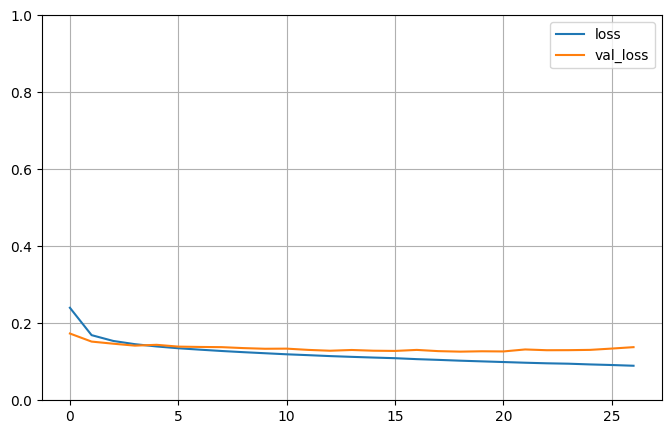

In [ ]:
pd.DataFrame(history_1.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

In [ ]:
# Đánh giá trên tập Test (Dữ liệu hoàn toàn mới)
test_loss, test_acc = model_1.evaluate(X_test, y_test)

812/812 ━━━━━━━━━━━━━━━━━━━━ 1s 773us/step - f1_score: 0.6157 - loss: 0.1235


In [ ]:
# model mẫu 
model_1_1 = tf.keras.models.Sequential()
model_1_1.add(tf.keras.layers.Dense(300, activation="relu", input_shape=[input_dim])) 
model_1_1.add(tf.keras.layers.Dense(100, activation="relu")) 
model_1_1.add(tf.keras.layers.Dense(1, activation="sigmoid"))

model_1_1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy", 
    metrics=["accuracy"]
)

# Huấn luyện mô hình
history_1_1 = model_1_1.fit(
    X_train, y_train, 
    epochs=100, 
    validation_data=(X_val, y_val),
    callbacks=[early_step]
    )

Epoch 1/100


c:\CodePython\ML-phantichdulieu\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2436/2436 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8991 - loss: 0.2369 - val_accuracy: 0.9281 - val_loss: 0.1750
Epoch 2/100
2436/2436 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9298 - loss: 0.1670 - val_accuracy: 0.9376 - val_loss: 0.1510
Epoch 3/100
2436/2436 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9370 - loss: 0.1510 - val_accuracy: 0.9414 - val_loss: 0.1422
Epoch 4/100
2436/2436 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9403 - loss: 0.1416 - val_accuracy: 0.9426 - val_loss: 0.1394
Epoch 5/100
2436/2436 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9425 - loss: 0.1359 - val_accuracy: 0.9430 - val_loss: 0.1379
Epoch 6/100
2436/2436 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9447 - loss: 0.1310 - val_accuracy: 0.9435 - val_loss: 0.1368
Epoch 7/100
2436/2436 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9463 - loss: 0.1271 - val_accuracy: 0.9428 - val_loss: 0.1366
Epoch 8/100
2436/2436 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9478 - loss: 0.1238 - val_

In [ ]:
# Đánh giá trên tập Test (Dữ liệu hoàn toàn mới)
test_loss, test_acc = model_1_1.evaluate(X_test, y_test)


812/812 ━━━━━━━━━━━━━━━━━━━━ 1s 708us/step - accuracy: 0.9266 - loss: 0.1744


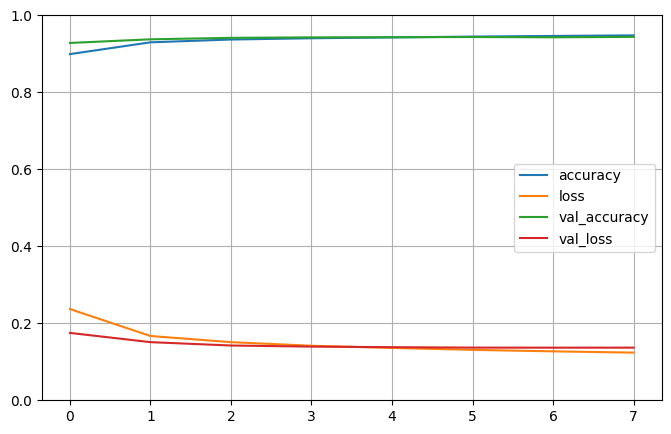

In [ ]:
pd.DataFrame(history_1_1.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

In [ ]:
from sklearn.metrics import classification_report
y_pred_prob = model_1_1.predict(X_val)
y_pred_labels = (y_pred_prob > 0.5).astype(int)
print(classification_report(y_val, y_pred_labels))

812/812 ━━━━━━━━━━━━━━━━━━━━ 1s 688us/step
              precision    recall  f1-score   support

         0.0       0.92      0.96      0.94     14677
         1.0       0.94      0.89      0.92     11299

    accuracy                           0.93     25976
   macro avg       0.93      0.92      0.93     25976
weighted avg       0.93      0.93      0.93     25976



In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_step = EarlyStopping(
    monitor='val_loss',        # Chỉ số cần theo dõi (Nên ưu tiên val_loss)
    patience=5,                # Cho phép mô hình dậm chân tại chỗ tối đa 8 vòng trước khi ngắt
    restore_best_weights=True  # Lấy lại bộ trọng số (weights) ở vòng có kết quả tốt nhất
)

#### 3.2 Model 2

In [ ]:
model_2 = tf.keras.models.Sequential()
model_2.add(tf.keras.layers.Dense(512, activation="relu", input_shape=[input_dim]))
model_2.add(tf.keras.layers.Dropout(0.3)) 
model_2.add(tf.keras.layers.Dense(256, activation="relu"))
model_2.add(tf.keras.layers.Dropout(0.2))
model_2.add(tf.keras.layers.Dense(128, activation="relu"))
model_2.add(tf.keras.layers.Dropout(0.1))
model_2.add(tf.keras.layers.Dense(1, activation="sigmoid"))

model_2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy", 
    metrics=["accuracy"]
)

# Huấn luyện mô hình
history_2 = model_2.fit(
    X_train, y_train, 
    epochs=100, 
    validation_data=(X_val, y_val),
    callbacks=[early_step]
    )

Epoch 1/100


c:\CodePython\ML-phantichdulieu\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2436/2436 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8942 - loss: 0.2523 - val_accuracy: 0.9276 - val_loss: 0.1725
Epoch 2/100
2436/2436 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9250 - loss: 0.1809 - val_accuracy: 0.9349 - val_loss: 0.1573
Epoch 3/100
2436/2436 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9310 - loss: 0.1646 - val_accuracy: 0.9375 - val_loss: 0.1465
Epoch 4/100
2436/2436 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9349 - loss: 0.1553 - val_accuracy: 0.9398 - val_loss: 0.1417
Epoch 5/100
2436/2436 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9379 - loss: 0.1498 - val_accuracy: 0.9405 - val_loss: 0.1390
Epoch 6/100
2436/2436 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9403 - loss: 0.1445 - val_accuracy: 0.9401 - val_loss: 0.1430
Epoch 7/100
2436/2436 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9406 - loss: 0.1411 - val_accuracy: 0.9435 - val_loss: 0.1330
Epoch 8/100
2436/2436 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9424 - loss: 0.1383 - val_

In [ ]:
model_2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 512)            │        12,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 531,461 (2.03 MB)

 Trainable params: 177,153 (692.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 354,308 (1.35 MB)

In [ ]:
# Đánh giá trên tập Test (Dữ liệu hoàn toàn mới)
test_loss, test_acc = model_2.evaluate(X_test, y_test)


812/812 ━━━━━━━━━━━━━━━━━━━━ 1s 789us/step - accuracy: 0.9502 - loss: 0.1193


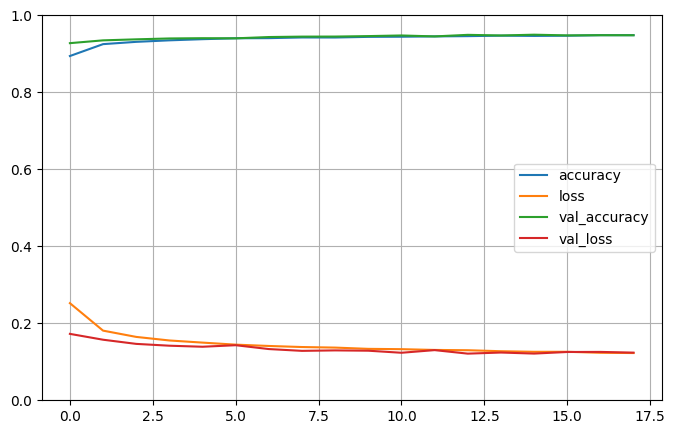

In [ ]:
pd.DataFrame(history_2.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

In [ ]:
from sklearn.metrics import classification_report
y_pred_prob = model_2.predict(X_val)
y_pred_labels = (y_pred_prob > 0.5).astype(int)
print(classification_report(y_val, y_pred_labels))

812/812 ━━━━━━━━━━━━━━━━━━━━ 1s 600us/step
              precision    recall  f1-score   support

         0.0       0.95      0.96      0.96     14677
         1.0       0.95      0.93      0.94     11299

    accuracy                           0.95     25976
   macro avg       0.95      0.95      0.95     25976
weighted avg       0.95      0.95      0.95     25976



### 4. Đánh giá kết quả

Sau khi chạy thử model_1 với thước đo là *F1-score* thì nhóm em thấy kết quả khá kém `f1_score: 0.6157 - loss: 0.1235` nhưng khi chạy lại bằng thước đo *Accuracy* thì model cho ra kết quả khá tốt `accuracy: 0.9266 - loss: 0.1744`

Khi thấy vấn đề này chúng em đã tìm hiểu và cho ra kết quả như sau
Với `F1-Score`: F1 được tính dựa trên `Precision` và `Recall` theo công thức  
$F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$  
Đây là một phép tính phi tuyến tính. Nếu Keras tính `F1-score` cho từng lô ví dụ 32 dòng, sau đó lấy trung bình cộng `F1-score` của tất cả các lô ở cuối epoch, kết quả trả về sẽ sai lệch hoàn toàn so với `F1-score` thực tế của toàn bộ tập dữ liệu.

Nên tại đây nhóm tụi em sử dụng hàm `classification_report` của `Sklearn` để tính chỉ số `F1-score` ở `model_1_1`

**Bảng đánh giá model**

| Tên model| Thông số|Kết quả|
|-----------------:|----------------:|----------------:|
|Model_1|2 lớp dense *(300,100)*, 0 dropout ,optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="binary_crossentropy", metrics=["f1_score"]|**F1-score: 0.6157 - loss: 0.1235**|
| Model_1_1 |2 lớp dense *(300,100)*, 0 dropout, optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="binary_crossentropy", metrics=["accuracy"]  | **accuracy: 0.9266 - loss: 0.1744**|
|Model_2| 3 lớp dense *(512,256,128)*, 3 lớp dropout *(0.3,0.2,0.1)*, optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="binary_crossentropy", metrics=["accuracy"] |**accuracy: 0.9502 - loss: 0.1193**|

Nhìn qua thì có vẽ thấy `model_1_1` kết quả train tốt hơn `Model_2` nhưng thực tế ở model_1_1 xuất hiện hiện tượng Overfit khá rõ ràng khi nhóm em quan sát thông qua biểu đồ.
- Nguyên nhân được nhóm em đưa ra cho vấn đề Overfit này đó:
    1. Do `model` không có các lớp `dropout` và thông số lớp `dense` khá lớn nên sẽ dẫn đến hiện tượng `Overfit`.
    2. Do việc sử dụng thông số `Early Stopping` là 8, dẫn đến việc mô hình không thể phát hiện `Overfit` sớm để dừng vòng lập.

**Đánh giá về model_2:**  
- Do đã được sử dụng các lớp Dropout luân phiên các lớp `dense` và giảm thông số `EarlyStopping` = *5* thì model trả về kết quả khá tốt, hiện tượng `Overfit` đã được giải quyết.

**Thông số F1-Score**

||model_1_1|model_2|
|-----------------:|----------------:|----------------:|
|Nhóm 0|0.94|0.96|
|Nhóm 1|0.92|0.94|

Sau khi đã thử các các phương pháp xử lý `Outlier` thì nhóm em nhận thấy không có sự ảnh hưởng quá lớn đến kết quả chạy model

Đánh giá chung từ các dữ liệu trên ta thấy được `model_2` chạy tốt nhất cho ra các thông số `accuracy` và `f1-score` lý tưởng.